# Protein Sequence Language Model

## Building a Mini GPT from Scratch in Pure JAX

**Scenario**: A computational biology lab wants to model the **"grammar" of proteins** — learning which amino acid sequences are plausible. Protein language models are used in drug design, enzyme engineering, and variant effect prediction.

We build a **decoder-only transformer** (GPT-style) entirely from scratch using JAX. The model is trained to predict the next amino acid given previous ones, learning the statistical patterns of three protein families.

**JAX concepts in action**:

| Concept | How we use it |
|---------|---------------|
| **PyTrees** | Deeply nested parameter dict (embeddings → blocks → attention/FFN → weights) |
| **vmap** | Batch the loss computation across sequences |
| **grad / value_and_grad** | Backprop through the entire transformer |
| **jit** | Compile the training step for speed |
| **jax.nn** | Softmax, GELU, log_softmax |
| **Functional purity** | Adam optimizer as explicit state passing |

In [2]:
import jax
import jax.numpy as jnp
from jax import random, jit, grad, value_and_grad, vmap
import matplotlib.pyplot as plt
import time

# Amino acid alphabet
AA = "ACDEFGHIKLMNPQRSTVWY"
VOCAB_SIZE = len(AA)  # 20

# Model hyperparameters
D_MODEL = 64
N_HEADS = 4
D_HEAD = D_MODEL // N_HEADS  # 16
FF_DIM = 256
N_LAYERS = 2
MAX_SEQ_LEN = 64

print(f"JAX {jax.__version__} | Devices: {jax.devices()}")
print(f"Model: {N_LAYERS} layers, {N_HEADS} heads, d_model={D_MODEL}")

JAX 0.9.0.1 | Devices: [CpuDevice(id=0)]
Model: 2 layers, 4 heads, d_model=64


---

## 1 — Protein Sequence Data

We generate synthetic sequences from **three protein families**, each with a characteristic amino acid composition and a short signature **motif**:

| Family | Dominant residues | Motif | Biology |
|--------|------------------|-------|---------|
| Alpha-helix | A, E, K, L | AELK | Coiled-coil domains |
| Beta-sheet | V, I, F, Y | VIVF | Immunoglobulin folds |
| Disordered | S, G, P, D | SPGN | Flexible linker regions |

In [3]:
SEQ_LEN = 48
N_PER_FAMILY = 200
FAMILY_NAMES = ["Alpha-helix", "Beta-sheet", "Disordered"]

# Amino acid frequency weights per family (unnormalized)
_weights = jnp.array([
    #  A  C  D  E  F  G  H  I  K  L  M  N  P  Q  R  S  T  V  W  Y
    [  5, 1, 1, 5, 1, 1, 1, 1, 5, 5, 2, 1, 1, 2, 1, 2, 2, 2, 1, 1],  # helix
    [  1, 1, 1, 1, 4, 1, 1, 5, 1, 3, 1, 1, 1, 1, 1, 2, 3, 5, 2, 4],  # sheet
    [  1, 1, 4, 1, 1, 4, 1, 1, 1, 1, 1, 4, 4, 2, 1, 4, 2, 1, 1, 1],  # disordered
], dtype=jnp.float32)
family_probs = _weights / _weights.sum(axis=1, keepdims=True)

# Signature motifs (amino acid indices)
family_motifs = [
    jnp.array([0, 3, 9, 8]),    # AELK
    jnp.array([17, 7, 17, 4]),  # VIVF
    jnp.array([15, 12, 5, 11]), # SPGN
]

key = random.PRNGKey(42)

all_seqs = []
all_labels = []

for fam in range(3):
    key, k1, k2 = random.split(key, 3)
    seqs = random.choice(k1, VOCAB_SIZE, shape=(N_PER_FAMILY, SEQ_LEN), p=family_probs[fam])
    
    # Insert motif at 2 random positions per sequence
    motif = family_motifs[fam]
    positions = random.randint(k2, (N_PER_FAMILY, 2), 3, SEQ_LEN - len(motif) - 3)
    for i in range(N_PER_FAMILY):
        for j in range(2):
            p = int(positions[i, j])
            seqs = seqs.at[i, p:p+len(motif)].set(motif)
    
    all_seqs.append(seqs)
    all_labels.append(jnp.full(N_PER_FAMILY, fam))

# Shuffle
data = jnp.concatenate(all_seqs)
labels = jnp.concatenate(all_labels)
key, shuffle_key = random.split(key)
perm = random.permutation(shuffle_key, len(data))
data, labels = data[perm], labels[perm]

print(f"Dataset: {data.shape[0]} sequences × {data.shape[1]} residues")
print(f"Example: {''.join(AA[int(t)] for t in data[0])}")

Dataset: 600 sequences × 48 residues
Example: ETSPPLQVTNEFMLVIVFIIAGIVIEQIVIVFAWCFAGVTVYYIFTLR


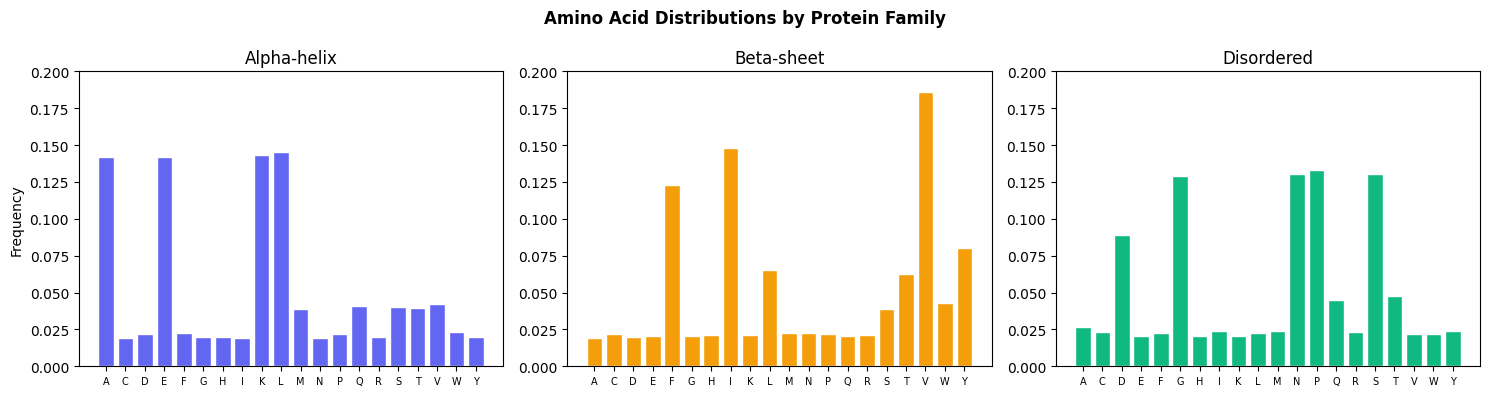

In [4]:
COLORS = ["#6366f1", "#f59e0b", "#10b981"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for fam in range(3):
    fam_seqs = data[labels == fam]
    freqs = jnp.array([jnp.mean(fam_seqs == aa) for aa in range(VOCAB_SIZE)])
    axes[fam].bar(range(VOCAB_SIZE), freqs, color=COLORS[fam], edgecolor="white")
    axes[fam].set_xticks(range(VOCAB_SIZE))
    axes[fam].set_xticklabels(list(AA), fontsize=7)
    axes[fam].set_title(f"{FAMILY_NAMES[fam]}")
    axes[fam].set_ylabel("Frequency" if fam == 0 else "")
    axes[fam].set_ylim(0, 0.20)
plt.suptitle("Amino Acid Distributions by Protein Family", fontweight="bold")
plt.tight_layout()
plt.show()

---

## 2 — Transformer Architecture

We implement a **decoder-only transformer** (GPT-style) with pre-norm residual connections:

$$x = x + \text{MultiHeadAttention}(\text{LayerNorm}(x))$$
$$x = x + \text{FFN}(\text{LayerNorm}(x))$$

The **scaled dot-product attention** with causal masking:

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}} + M\right) V$$

where $M$ is $-\infty$ for future positions (causal mask), and $Q = xW^Q$, $K = xW^K$, $V = xW^V$.

All parameters live in a single **PyTree** — a nested dict that JAX transformations traverse natively.

In [5]:
def init_params(key):
    """Initialize all transformer parameters as a nested PyTree."""
    keys = random.split(key, 3 + N_LAYERS * 6)
    ki = 0

    def linear_init(k, fan_in, fan_out):
        return {
            "w": random.normal(k, (fan_in, fan_out)) * (2.0 / fan_in) ** 0.5,
            "b": jnp.zeros(fan_out),
        }

    def ln_init():
        return {"scale": jnp.ones(D_MODEL), "bias": jnp.zeros(D_MODEL)}

    params = {
        "embedding": {
            "token_emb": random.normal(keys[0], (VOCAB_SIZE, D_MODEL)) * 0.02,
            "pos_emb": random.normal(keys[1], (MAX_SEQ_LEN, D_MODEL)) * 0.02,
        },
        "blocks": [],
        "ln_final": ln_init(),
        "head": linear_init(keys[2], D_MODEL, VOCAB_SIZE),
    }
    ki = 3

    for _ in range(N_LAYERS):
        block = {
            "ln1": ln_init(),
            "attn": {
                "q": linear_init(keys[ki],   D_MODEL, D_MODEL),
                "k": linear_init(keys[ki+1], D_MODEL, D_MODEL),
                "v": linear_init(keys[ki+2], D_MODEL, D_MODEL),
                "o": linear_init(keys[ki+3], D_MODEL, D_MODEL),
            },
            "ln2": ln_init(),
            "ffn": {
                "up": linear_init(keys[ki+4], D_MODEL, FF_DIM),
                "down": linear_init(keys[ki+5], FF_DIM, D_MODEL),
            },
        }
        params["blocks"].append(block)
        ki += 6

    return params

key, init_key = random.split(key)
params = init_params(init_key)

# Inspect PyTree structure
shapes = jax.tree.map(lambda x: x.shape, params)
n_params = sum(x.size for x in jax.tree.leaves(params))
print(f"Total parameters: {n_params:,}")
print(f"\nPyTree structure:")
for k, v in shapes.items():
    if k == "blocks":
        print(f"  blocks: [{len(v)} layers]")
        for sub_k, sub_v in v[0].items():
            print(f"    {sub_k}: {sub_v}")
    else:
        print(f"  {k}: {v}")

Total parameters: 106,772

PyTree structure:
  blocks: [2 layers]
    attn: {'k': {'b': (64,), 'w': (64, 64)}, 'o': {'b': (64,), 'w': (64, 64)}, 'q': {'b': (64,), 'w': (64, 64)}, 'v': {'b': (64,), 'w': (64, 64)}}
    ffn: {'down': {'b': (64,), 'w': (256, 64)}, 'up': {'b': (256,), 'w': (64, 256)}}
    ln1: {'bias': (64,), 'scale': (64,)}
    ln2: {'bias': (64,), 'scale': (64,)}
  embedding: {'pos_emb': (64, 64), 'token_emb': (20, 64)}
  head: {'b': (20,), 'w': (64, 20)}
  ln_final: {'bias': (64,), 'scale': (64,)}


---

## 3 — Building Blocks

Each component is a **pure function** — no hidden state, no side effects. This is what makes them compatible with `jit`, `grad`, and `vmap`.

In [6]:
def layer_norm(params, x, eps=1e-5):
    """x: (seq_len, D_MODEL) → (seq_len, D_MODEL)"""
    mean = jnp.mean(x, axis=-1, keepdims=True)
    var = jnp.var(x, axis=-1, keepdims=True)
    return params["scale"] * (x - mean) / jnp.sqrt(var + eps) + params["bias"]


def multi_head_attention(params, x, mask):
    """Causal multi-head self-attention.
    x: (seq_len, D_MODEL), mask: (seq_len, seq_len) boolean
    """
    seq_len = x.shape[0]

    # Project to Q, K, V
    Q = x @ params["q"]["w"] + params["q"]["b"]
    K = x @ params["k"]["w"] + params["k"]["b"]
    V = x @ params["v"]["w"] + params["v"]["b"]

    # Reshape: (seq_len, D_MODEL) → (N_HEADS, seq_len, D_HEAD)
    Q = Q.reshape(seq_len, N_HEADS, D_HEAD).transpose(1, 0, 2)
    K = K.reshape(seq_len, N_HEADS, D_HEAD).transpose(1, 0, 2)
    V = V.reshape(seq_len, N_HEADS, D_HEAD).transpose(1, 0, 2)

    # Scaled dot-product attention
    scores = (Q @ K.transpose(0, 2, 1)) / jnp.sqrt(float(D_HEAD))
    scores = jnp.where(mask[None], scores, -1e9)  # causal masking
    weights = jax.nn.softmax(scores, axis=-1)

    # Combine heads
    out = (weights @ V).transpose(1, 0, 2).reshape(seq_len, D_MODEL)
    return out @ params["o"]["w"] + params["o"]["b"]


def ffn(params, x):
    """Position-wise feed-forward network with GELU."""
    h = jax.nn.gelu(x @ params["up"]["w"] + params["up"]["b"])
    return h @ params["down"]["w"] + params["down"]["b"]


def transformer_block(params, x, mask):
    """Pre-norm transformer block with residual connections."""
    x = x + multi_head_attention(params["attn"], layer_norm(params["ln1"], x), mask)
    x = x + ffn(params["ffn"], layer_norm(params["ln2"], x))
    return x


print("Building blocks defined: layer_norm, multi_head_attention, ffn, transformer_block")

Building blocks defined: layer_norm, multi_head_attention, ffn, transformer_block


---

## 4 — Forward Pass & Batching with vmap

We write `forward` for a **single sequence**, then `vmap` it across the batch — exactly like in the drug response project, but now over sequences instead of tabular samples.

In [7]:
def forward(params, tokens):
    """Forward pass for a single sequence.
    tokens: (seq_len,) int → logits: (seq_len, VOCAB_SIZE)
    """
    seq_len = tokens.shape[0]

    # Token + positional embedding
    x = params["embedding"]["token_emb"][tokens] + params["embedding"]["pos_emb"][:seq_len]

    # Causal mask: position i can only attend to positions ≤ i
    mask = jnp.tril(jnp.ones((seq_len, seq_len), dtype=bool))

    # Transformer blocks (Python for-loop unrolls at JIT trace time)
    for block_params in params["blocks"]:
        x = transformer_block(block_params, x, mask)

    # Project to vocabulary
    x = layer_norm(params["ln_final"], x)
    return x @ params["head"]["w"] + params["head"]["b"]


# Test: single sequence
logits_single = forward(params, data[0])
print(f"Single sequence → logits: {logits_single.shape}")

# Batch with vmap (params shared, map over sequences)
forward_batch = vmap(forward, in_axes=(None, 0))
logits_batch = forward_batch(params, data[:8])
print(f"Batch of 8      → logits: {logits_batch.shape}")
print(f"Match: {jnp.allclose(logits_single, logits_batch[0])}")

Single sequence → logits: (48, 20)
Batch of 8      → logits: (8, 48, 20)
Match: True


---

## 5 — Loss & Automatic Differentiation

The model is trained with **next-token prediction**: given tokens $t_1, \ldots, t_{n-1}$, predict $t_2, \ldots, t_n$.

$$\mathcal{L} = -\frac{1}{N}\sum_{i=1}^{N-1} \log p_\theta(t_{i+1} \mid t_1, \ldots, t_i)$$

`jax.grad` differentiates through the entire transformer — attention, GELU, layer norm, embedding lookups — all automatically.

In [8]:
def loss_single(params, tokens):
    """Cross-entropy loss for one sequence (next-token prediction)."""
    logits = forward(params, tokens)
    # Predict tokens[1:] from logits[:-1]
    log_probs = jax.nn.log_softmax(logits[:-1], axis=-1)
    targets = tokens[1:]
    return -jnp.mean(log_probs[jnp.arange(targets.shape[0]), targets])


def batch_loss(params, tokens_batch):
    """Average loss over a batch — vmap does the heavy lifting."""
    return jnp.mean(vmap(loss_single, in_axes=(None, 0))(params, tokens_batch))


# Test: compute loss and gradients
loss_val = batch_loss(params, data[:32])
print(f"Initial loss: {float(loss_val):.4f} (random baseline ≈ {float(jnp.log(VOCAB_SIZE)):.4f})")

# value_and_grad: loss + gradient PyTree in one pass
loss_val, grads = value_and_grad(batch_loss)(params, data[:32])
print(f"\nGradient PyTree has same structure as params:")
print(f"  head/w grad shape: {grads['head']['w'].shape}")
print(f"  block 0 attn/q/w grad norm: {float(jnp.linalg.norm(grads['blocks'][0]['attn']['q']['w'])):.4f}")

Initial loss: 3.8358 (random baseline ≈ 2.9957)

Gradient PyTree has same structure as params:
  head/w grad shape: (64, 20)
  block 0 attn/q/w grad norm: 0.3445


---

## 6 — Adam Optimizer & JIT Compilation

We implement **Adam** as pure state passing — the optimizer state (first and second moment estimates) is a PyTree with the same structure as the parameters:

$$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t \qquad v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$$
$$\theta_{t+1} = \theta_t - \alpha \cdot \frac{m_t / (1 - \beta_1^t)}{\sqrt{v_t / (1 - \beta_2^t)} + \epsilon}$$

The entire training step — forward, loss, backward, parameter update — is wrapped in `@jit`.

In [9]:
def init_adam_state(params):
    return {
        "params": params,
        "m": jax.tree.map(jnp.zeros_like, params),  # first moment
        "v": jax.tree.map(jnp.zeros_like, params),  # second moment
        "step": jnp.array(0, dtype=jnp.float32),
    }


@jit
def train_step(state, tokens_batch, lr):
    """JIT-compiled training step: forward + backward + Adam update."""
    loss_val, grads = value_and_grad(batch_loss)(state["params"], tokens_batch)

    step = state["step"] + 1
    beta1, beta2, eps = 0.9, 0.999, 1e-8

    # Update moments
    m = jax.tree.map(lambda m, g: beta1 * m + (1 - beta1) * g, state["m"], grads)
    v = jax.tree.map(lambda v, g: beta2 * v + (1 - beta2) * g**2, state["v"], grads)

    # Bias correction
    m_hat = jax.tree.map(lambda m: m / (1 - beta1**step), m)
    v_hat = jax.tree.map(lambda v: v / (1 - beta2**step), v)

    # Update params
    new_params = jax.tree.map(
        lambda p, m, v: p - lr * m / (jnp.sqrt(v) + eps),
        state["params"], m_hat, v_hat,
    )

    return {"params": new_params, "m": m, "v": v, "step": step}, loss_val


print("Adam optimizer + JIT-compiled train_step defined.")

Adam optimizer + JIT-compiled train_step defined.


---

## 7 — Training

In [10]:
BATCH_SIZE = 64
N_EPOCHS = 80
LR = 3e-3
n_batches = len(data) // BATCH_SIZE

key, init_key = random.split(key)
params = init_params(init_key)
state = init_adam_state(params)

losses = []
t_start = time.perf_counter()

for epoch in range(N_EPOCHS):
    # Shuffle at each epoch
    key, shuffle_key = random.split(key)
    perm = random.permutation(shuffle_key, len(data))
    data_shuffled = data[perm]

    epoch_loss = 0.0
    for i in range(n_batches):
        batch = data_shuffled[i * BATCH_SIZE : (i + 1) * BATCH_SIZE]
        state, loss_val = train_step(state, batch, LR)
        epoch_loss += float(loss_val)

    avg_loss = epoch_loss / n_batches
    losses.append(avg_loss)

    if epoch % 10 == 0 or epoch == N_EPOCHS - 1:
        elapsed = time.perf_counter() - t_start
        print(f"Epoch {epoch:3d} | Loss: {avg_loss:.4f} | Time: {elapsed:.1f}s")

trained_params = state["params"]

Epoch   0 | Loss: 3.2184 | Time: 1.2s
Epoch  10 | Loss: 2.5393 | Time: 3.0s
Epoch  20 | Loss: 2.3647 | Time: 4.7s
Epoch  30 | Loss: 2.0847 | Time: 6.3s
Epoch  40 | Loss: 1.7385 | Time: 7.9s
Epoch  50 | Loss: 1.4192 | Time: 9.9s
Epoch  60 | Loss: 1.1361 | Time: 12.0s
Epoch  70 | Loss: 0.9181 | Time: 14.3s
Epoch  79 | Loss: 0.8056 | Time: 15.9s


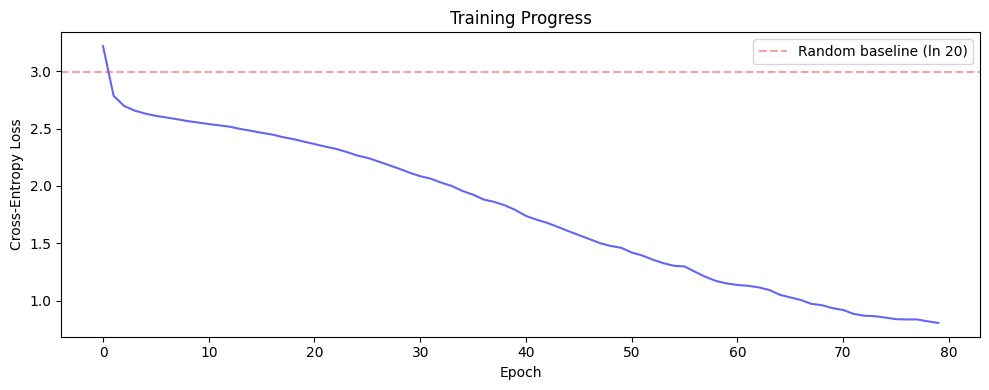

In [11]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(losses, color="#6366f1", linewidth=1.5)
ax.axhline(jnp.log(VOCAB_SIZE), color="#ef4444", linestyle="--", alpha=0.5, label=f"Random baseline (ln {VOCAB_SIZE})")
ax.set_xlabel("Epoch")
ax.set_ylabel("Cross-Entropy Loss")
ax.set_title("Training Progress")
ax.legend()
plt.tight_layout()
plt.show()

---

## 8 — Sequence Generation

We generate sequences **autoregressively**: start with one amino acid, then repeatedly predict the next token by sampling from the model's output distribution.

The **temperature** parameter controls diversity: lower → more deterministic, higher → more random.

In [12]:
def generate(params, key, length, temperature=1.0):
    """Autoregressive sequence generation."""
    key, start_key = random.split(key)
    tokens = jnp.array([random.randint(start_key, (), 0, VOCAB_SIZE)])

    for _ in range(length - 1):
        logits = forward(params, tokens)
        next_logits = logits[-1] / temperature
        key, sample_key = random.split(key)
        next_token = random.categorical(sample_key, next_logits)
        tokens = jnp.concatenate([tokens, next_token[None]])

    return tokens


def tokens_to_str(tokens):
    return "".join(AA[int(t)] for t in tokens)


# Generate sequences at different temperatures
print("Generated protein sequences:\n")
for temp in [0.5, 0.8, 1.0, 1.2]:
    key, gen_key = random.split(key)
    seq = generate(trained_params, gen_key, SEQ_LEN, temperature=temp)
    print(f"  T={temp:.1f}  {tokens_to_str(seq)}")

print(f"\nTraining examples for comparison:")
for i in range(3):
    fam = int(labels[i])
    print(f"  [{FAMILY_NAMES[fam]:12s}]  {tokens_to_str(data[i])}")

Generated protein sequences:

  T=0.5  VDLFYIKAELKAAEGKVAEGSELKAVTAAELATKEELAYKAIAQNKIK
  T=0.8  LFQKEAELKYHACVDAELTMDMVATAAKYMLARAELSYMDMKALRKQL
  T=1.0  GQYVAVVIVFFTTTVCSVIWDTMTMIVINEWCQSTLTVIHTIVFQCIF
  T=1.2  MESQDYPPSESLNKNEPMGECRGSYGSPPGSSKAMNEGYPWEYSNMMN

Training examples for comparison:
  [Beta-sheet  ]  ETSPPLQVTNEFMLVIVFIIAGIVIEQIVIVFAWCFAGVTVYYIFTLR
  [Disordered  ]  PPSVAGSFADSSPGNQGNSYSSPGNDKYDPGDYSMQHQWGCNGHSNPA
  [Alpha-helix ]  EFTHARNSKAKREAWGWKMLTRQKPKVAELKAELKWGSFFKDEYKFTF


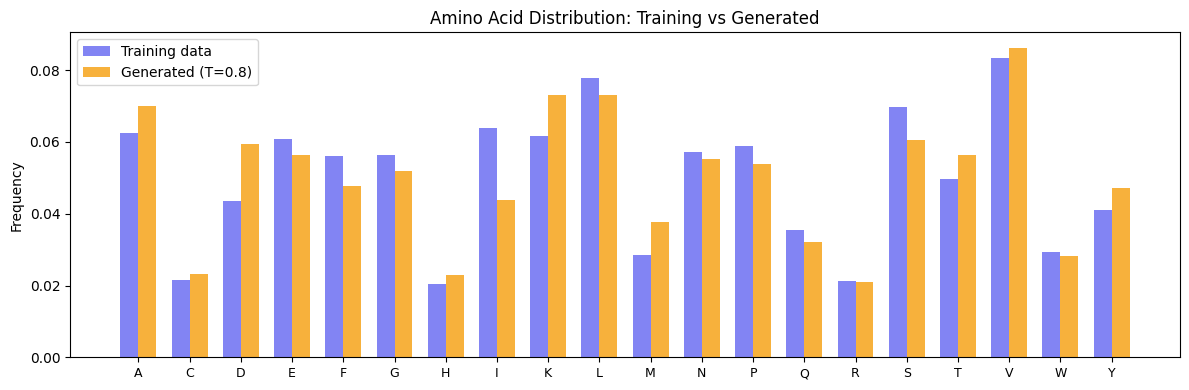

In [13]:
# Compare amino acid distributions: training data vs generated
n_gen = 100
generated_seqs = []
for i in range(n_gen):
    key, gen_key = random.split(key)
    generated_seqs.append(generate(trained_params, gen_key, SEQ_LEN, temperature=0.8))
generated_seqs = jnp.stack(generated_seqs)

train_freqs = jnp.array([jnp.mean(data == aa) for aa in range(VOCAB_SIZE)])
gen_freqs = jnp.array([jnp.mean(generated_seqs == aa) for aa in range(VOCAB_SIZE)])

fig, ax = plt.subplots(figsize=(12, 4))
x_pos = jnp.arange(VOCAB_SIZE)
width = 0.35
ax.bar(x_pos - width/2, train_freqs, width, label="Training data", color="#6366f1", alpha=0.8)
ax.bar(x_pos + width/2, gen_freqs, width, label="Generated (T=0.8)", color="#f59e0b", alpha=0.8)
ax.set_xticks(range(VOCAB_SIZE))
ax.set_xticklabels(list(AA), fontsize=9)
ax.set_ylabel("Frequency")
ax.set_title("Amino Acid Distribution: Training vs Generated")
ax.legend()
plt.tight_layout()
plt.show()

---

## 9 — Attention Visualization

Let's look at what the attention heads have learned. Different heads may specialize in different patterns — local neighbors, motif positions, or long-range dependencies.

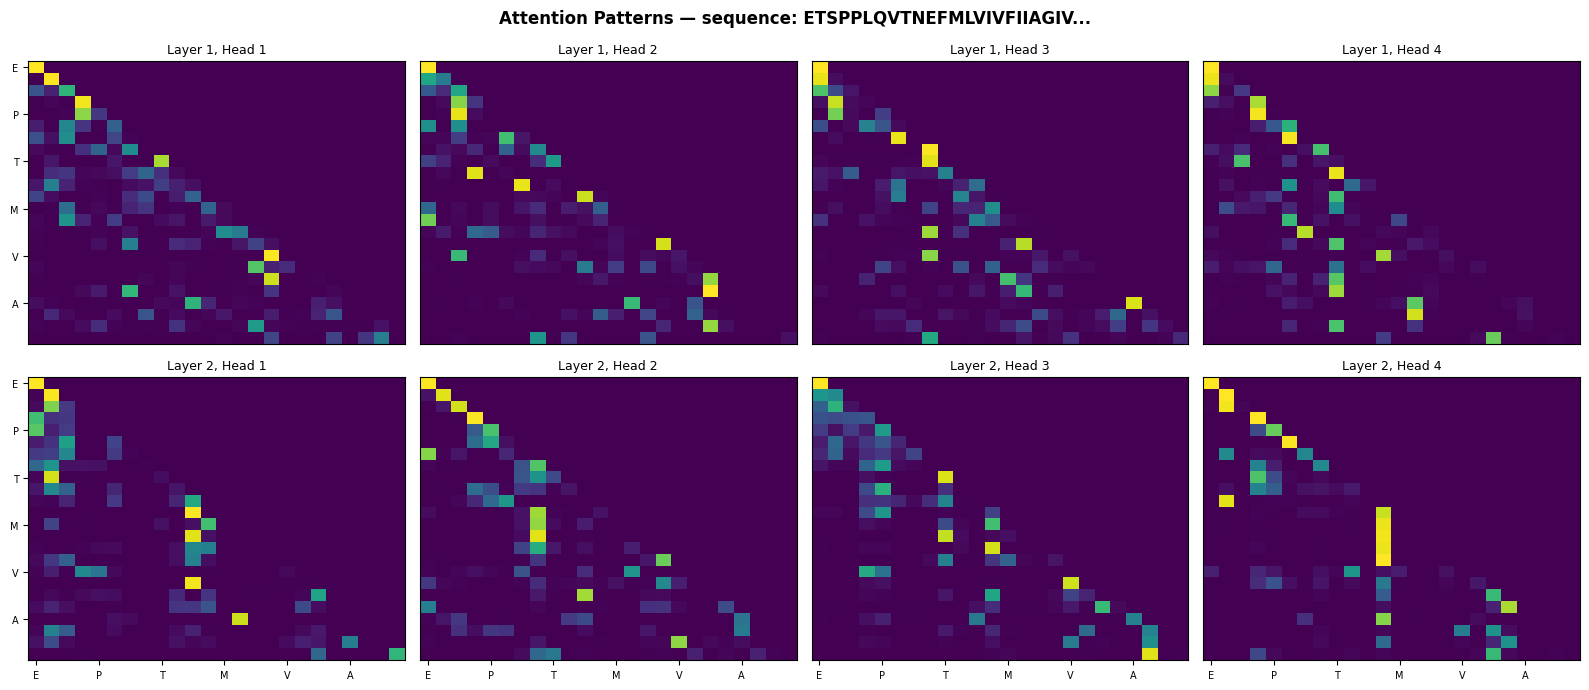

In [14]:
def get_attention_maps(params, tokens):
    """Run forward pass and collect attention weights from all layers."""
    seq_len = tokens.shape[0]
    x = params["embedding"]["token_emb"][tokens] + params["embedding"]["pos_emb"][:seq_len]
    mask = jnp.tril(jnp.ones((seq_len, seq_len), dtype=bool))

    all_weights = []
    for bp in params["blocks"]:
        h = layer_norm(bp["ln1"], x)
        ap = bp["attn"]

        Q = (h @ ap["q"]["w"] + ap["q"]["b"]).reshape(seq_len, N_HEADS, D_HEAD).transpose(1, 0, 2)
        K = (h @ ap["k"]["w"] + ap["k"]["b"]).reshape(seq_len, N_HEADS, D_HEAD).transpose(1, 0, 2)
        V = (h @ ap["v"]["w"] + ap["v"]["b"]).reshape(seq_len, N_HEADS, D_HEAD).transpose(1, 0, 2)

        scores = (Q @ K.transpose(0, 2, 1)) / jnp.sqrt(float(D_HEAD))
        scores = jnp.where(mask[None], scores, -1e9)
        weights = jax.nn.softmax(scores, axis=-1)
        all_weights.append(weights)

        out = (weights @ V).transpose(1, 0, 2).reshape(seq_len, D_MODEL)
        x = x + out @ ap["o"]["w"] + ap["o"]["b"]
        h2 = layer_norm(bp["ln2"], x)
        x = x + jax.nn.gelu(h2 @ bp["ffn"]["up"]["w"] + bp["ffn"]["up"]["b"]) @ bp["ffn"]["down"]["w"] + bp["ffn"]["down"]["b"]

    return all_weights


# Get attention maps for a sample sequence
sample_seq = data[0]
sample_str = tokens_to_str(sample_seq)
attn_maps = get_attention_maps(trained_params, sample_seq)

# Plot first 24 positions for readability
SHOW = 24
fig, axes = plt.subplots(N_LAYERS, N_HEADS, figsize=(16, 7))

for layer in range(N_LAYERS):
    for head in range(N_HEADS):
        ax = axes[layer, head]
        im = ax.imshow(attn_maps[layer][head, :SHOW, :SHOW], cmap="viridis", aspect="auto", vmin=0)
        ax.set_title(f"Layer {layer+1}, Head {head+1}", fontsize=9)
        if layer == N_LAYERS - 1:
            ax.set_xticks(range(0, SHOW, 4))
            ax.set_xticklabels([sample_str[i] for i in range(0, SHOW, 4)], fontsize=7)
        else:
            ax.set_xticks([])
        if head == 0:
            ax.set_yticks(range(0, SHOW, 4))
            ax.set_yticklabels([sample_str[i] for i in range(0, SHOW, 4)], fontsize=7)
        else:
            ax.set_yticks([])

fig.suptitle(f"Attention Patterns — sequence: {sample_str[:SHOW]}...", fontweight="bold")
plt.tight_layout()
plt.show()

---

## Summary

We built a **decoder-only transformer from scratch** in pure JAX and trained it to model protein sequences.

**Architecture implemented**:
- Token + positional embeddings
- Multi-head causal self-attention
- GELU feed-forward network
- Pre-norm residual connections
- Autoregressive generation with temperature sampling

**JAX concepts used**:

| Concept | Role in this project |
|---------|---------------------|
| **PyTrees** | ~107K parameters organized in a nested dict: embedding → blocks → attention Q/K/V/O + FFN → weights & biases |
| **vmap** | Batched loss computation — `vmap(loss_single)` over 64 sequences at once |
| **grad** | Backprop through the full transformer — attention, GELU, layer norm, embeddings |
| **jit** | Compiled training step: forward + backward + Adam update in one fused program |
| **State management** | Adam optimizer with explicit `{params, m, v, step}` state — no hidden mutability |
| **Functional purity** | Every function takes state in, returns state out — the foundation that makes all transformations composable |